# Tabular Foundation Model — Step-by-Step Tutorial

This notebook walks through every component of a minimal tabular foundation model.
By the end you'll understand:
- How to tokenize tabular rows for a transformer
- How to generate synthetic training tasks
- How to train the model
- How zero-shot inference works on real data

**Everything runs in ~5 min on CPU.**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

torch.manual_seed(42)
np.random.seed(42)
print('PyTorch:', torch.__version__)

PyTorch: 2.11.0+cpu


---
## Part 1: Visualise the Idea

Classic ML: train a **separate model** for each dataset.

Our approach: train **one model** that takes *any* dataset as input and predicts labels.

```
Input:  [x1,y1] [x2,y2] [x3,y3]  ← labeled support rows (context)
        [q1, ?] [q2, ?]           ← unlabeled query rows
        
Output:         [ŷ1]  [ŷ2]        ← predictions
```

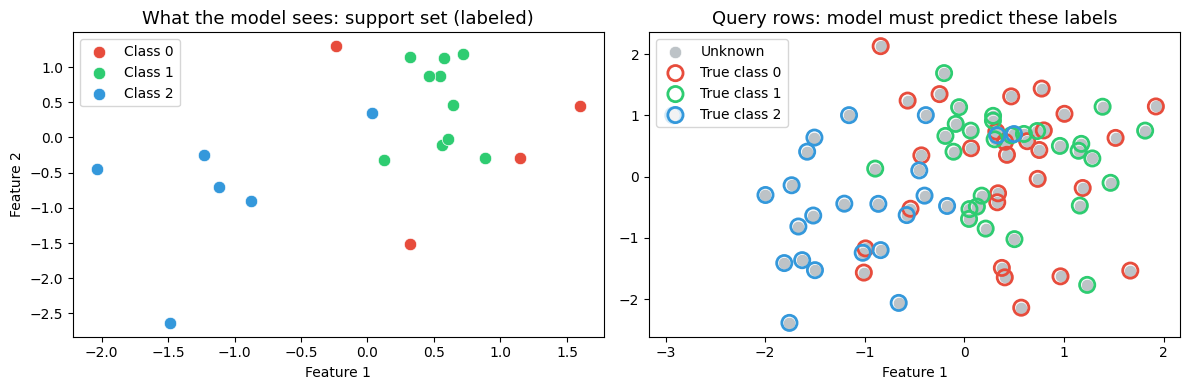

Support: 20 labeled rows  |  Query: 80 rows to predict


In [2]:
# Visualise a synthetic task
from data import sample_gmm, normalize

X, y = sample_gmm(n=100, D=2, C=3)
X = normalize(X)

# Split into support and query
n_support = 20
X_support, y_support = X[:n_support], y[:n_support]
X_query,   y_query   = X[n_support:], y[n_support:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e74c3c', '#2ecc71', '#3498db']
cmap   = ListedColormap(colors)

axes[0].set_title('What the model sees: support set (labeled)', fontsize=13)
for c, col in zip(range(3), colors):
    mask = y_support == c
    axes[0].scatter(X_support[mask, 0], X_support[mask, 1], c=col, s=80,
                    edgecolors='white', lw=0.5, label=f'Class {c}')
axes[0].legend()
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

axes[1].set_title('Query rows: model must predict these labels', fontsize=13)
axes[1].scatter(X_query[:, 0], X_query[:, 1], c='#bdc3c7', s=80,
                edgecolors='white', lw=0.5, label='Unknown')
# Overlay faint true labels for reference
for c, col in zip(range(3), colors):
    mask = y_query == c
    axes[1].scatter(X_query[mask, 0], X_query[mask, 1], facecolors='none',
                    edgecolors=col, s=120, linewidths=2, label=f'True class {c}')
axes[1].legend()
axes[1].set_xlabel('Feature 1')

plt.tight_layout()
plt.show()
print(f'Support: {n_support} labeled rows  |  Query: {len(X_query)} rows to predict')

---
## Part 2: The Tokenizer

Each row `x ∈ ℝᴰ` must become a `d_model`-dim vector.

```python
support token = Linear(x) + LabelEmbedding(y)
query   token = Linear(x) + LearnedUnknownVector
```

Support token shape: torch.Size([1, 3, 8])
Query token shape:   torch.Size([1, 2, 8])


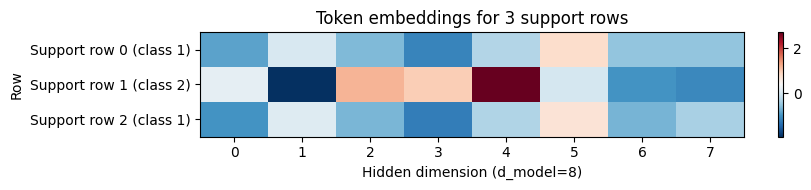

In [3]:
from model import FeatureTokenizer

tok = FeatureTokenizer(n_features=2, n_classes=3, d_model=8)

# Encode one batch of 3 support rows
x_s = X_support[:3].unsqueeze(0)  # (1, 3, 2)
y_s = y_support[:3].unsqueeze(0)  # (1, 3)
x_q = X_query[:2].unsqueeze(0)    # (1, 2, 2)

support_toks = tok.encode_support(x_s, y_s)
query_toks   = tok.encode_query(x_q)

print('Support token shape:', support_toks.shape)  # (1, 3, 8)
print('Query token shape:  ', query_toks.shape)    # (1, 2, 8)

# Visualise: the same features with different labels produce different tokens
fig, ax = plt.subplots(figsize=(9, 2))
tokens_np = support_toks.squeeze(0).detach().numpy()  # (3, 8)
im = ax.imshow(tokens_np, aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Hidden dimension (d_model=8)')
ax.set_ylabel('Row')
ax.set_yticks(range(3))
ax.set_yticklabels([f'Support row {i} (class {y_support[i].item()})' for i in range(3)])
ax.set_title('Token embeddings for 3 support rows')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
## Part 3: Synthetic Prior — Generating Training Tasks

We need *diverse* tasks so the model learns a general algorithm.
Let's visualise the three generators.

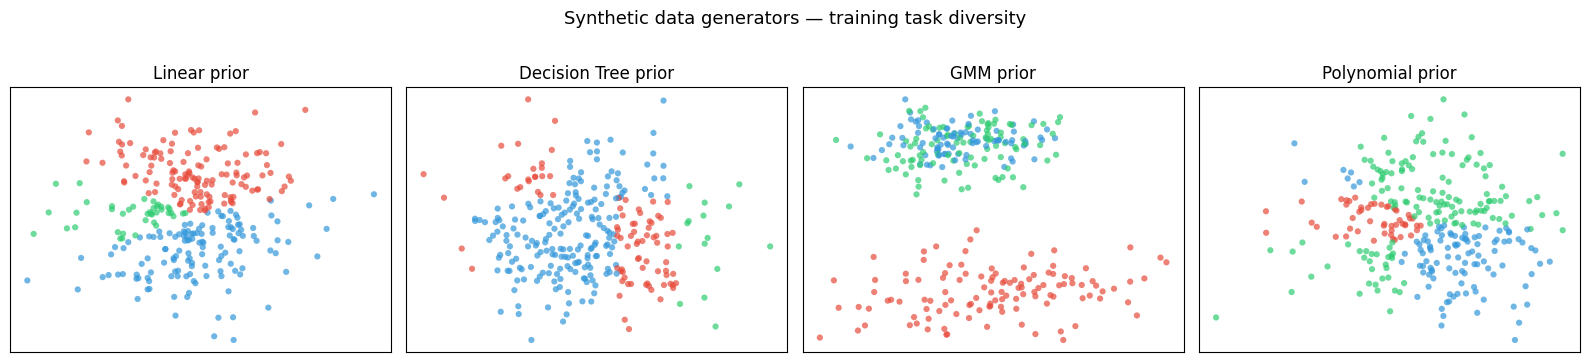

Each training step randomly samples from these generators.
The model can never memorise — it must learn to generalise.


In [4]:
from data import sample_linear, sample_tree, sample_gmm, sample_poly, normalize

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
titles = ['Linear', 'Decision Tree', 'GMM', 'Polynomial']
gens   = [sample_linear, sample_tree, sample_gmm, sample_poly]
cmap   = ListedColormap(['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'])

for ax, title, gen in zip(axes, titles, gens):
    X, y = gen(n=300, D=2, C=3)
    X = normalize(X).numpy()
    y = y.numpy()
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#e74c3c', '#2ecc71', '#3498db']),
               s=20, alpha=0.7, edgecolors='none')
    ax.set_title(f'{title} prior', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Synthetic data generators — training task diversity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('Each training step randomly samples from these generators.')
print('The model can never memorise — it must learn to generalise.')

---
## Part 4: Build and Inspect the Model

In [5]:
from model import TabularFoundationModel

model = TabularFoundationModel(
    n_features = 16,
    n_classes  = 10,
    d_model    = 128,
    n_heads    = 4,
    n_layers   = 4,
)

# Count parameters by component
def count_params(module):
    return sum(p.numel() for p in module.parameters())

print(f'Tokenizer:   {count_params(model.tokenizer):>8,} params')
print(f'Transformer: {count_params(model.transformer):>8,} params')
print(f'Output head: {count_params(model.output_head):>8,} params')
print(f'─────────────────────────────')
print(f'Total:       {count_params(model):>8,} params  (~{count_params(model)/1e6:.2f}M)')

# Test forward pass
B, N, M, D = 4, 32, 8, 16



logits = model(
    torch.randn(B, N, D),
    torch.randint(0, 10, (B, N)),
    torch.randn(B, M, D),
)
print(f'\nForward pass: logits shape = {tuple(logits.shape)}  ✓')

Tokenizer:      3,584 params
Transformer:  793,088 params
Output head:    1,290 params
─────────────────────────────
Total:        797,962 params  (~0.80M)

Forward pass: logits shape = (4, 8, 10)  ✓


/app/model.py:124: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


---
## Part 5: Train!

Training is just cross-entropy on query labels.
We run 3000 steps here — should take ~3 min on CPU.

In [17]:
import torch.nn.functional as F
from data import sample_batch

model = TabularFoundationModel(n_features=16, n_classes=10, d_model=128, n_layers=4, n_heads=4)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

N_STEPS   = 5000
LOG_EVERY = 100
history   = {'loss': [], 'acc': [], 'step': []}

for step in range(1, N_STEPS + 1):
    # Cosine LR schedule
    progress = step / N_STEPS
    lr = 3e-4 * 0.5 * (1 + np.cos(np.pi * progress))
    for g in optimizer.param_groups: g['lr'] = lr

    x_s, y_s, x_q, y_q = sample_batch(64, 32, 8, 16, 10)

    model.train()
    
    logits = model(x_s, y_s, x_q)                              # (64, 8, 10)
    loss   = F.cross_entropy(logits.reshape(-1, 10), y_q.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if step % LOG_EVERY == 0:
        with torch.no_grad():
            acc = (logits.argmax(-1) == y_q).float().mean().item()
        history['loss'].append(loss.item())
        history['acc'].append(acc)
        history['step'].append(step)
        print(f'step {step:4d} | loss {loss.item():.4f} | acc {acc:.3f}')

torch.save({'state_dict': model.state_dict(),
            'config': {'n_features':16,'n_classes':10,'d_model':128,'n_heads':4,'n_layers':4}},
           'tabfm.pt')
print('\nSaved: tabfm.pt')

/app/model.py:124: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


step  100 | loss 1.6426 | acc 0.480
step  200 | loss 1.7049 | acc 0.455
step  300 | loss 1.5642 | acc 0.518
step  400 | loss 1.4132 | acc 0.551
step  500 | loss 1.4267 | acc 0.547
step  600 | loss 1.4924 | acc 0.545
step  700 | loss 1.5253 | acc 0.482
step  800 | loss 1.5650 | acc 0.480
step  900 | loss 1.5096 | acc 0.527
step 1000 | loss 1.4187 | acc 0.518
step 1100 | loss 1.4841 | acc 0.520
step 1200 | loss 1.3572 | acc 0.531
step 1300 | loss 1.4164 | acc 0.510
step 1400 | loss 1.3928 | acc 0.531
step 1500 | loss 1.4209 | acc 0.533
step 1600 | loss 1.3859 | acc 0.523
step 1700 | loss 1.3297 | acc 0.559
step 1800 | loss 1.1923 | acc 0.607
step 1900 | loss 1.3973 | acc 0.543
step 2000 | loss 1.5629 | acc 0.477
step 2100 | loss 1.2897 | acc 0.543
step 2200 | loss 1.3793 | acc 0.549
step 2300 | loss 1.2444 | acc 0.578
step 2400 | loss 1.2824 | acc 0.539
step 2500 | loss 1.5394 | acc 0.471
step 2600 | loss 1.4953 | acc 0.486
step 2700 | loss 1.3663 | acc 0.562
step 2800 | loss 1.2594 | ac

In [18]:
#model = torch.load('tabfm.pt')

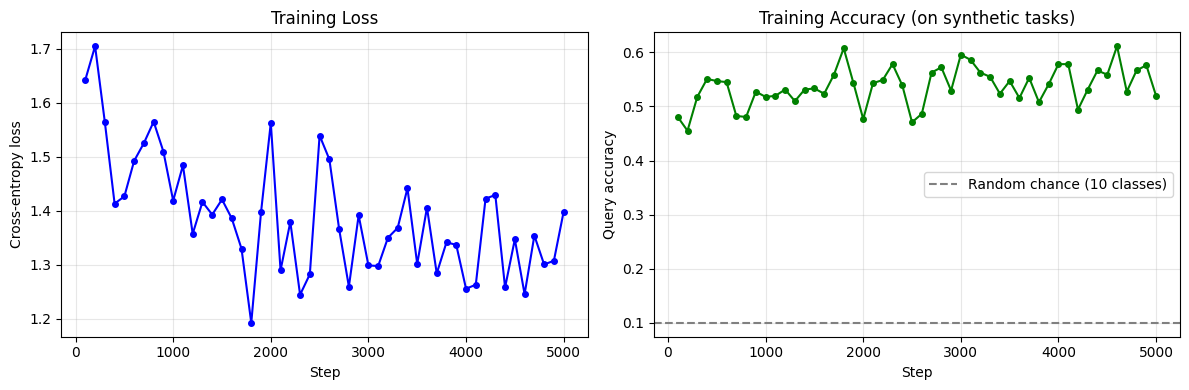

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['step'], history['loss'], 'b-o', ms=4)
ax1.set_xlabel('Step'); ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Training Loss')
ax1.grid(alpha=0.3)

ax2.plot(history['step'], history['acc'], 'g-o', ms=4)
ax2.axhline(0.1, ls='--', color='gray', label='Random chance (10 classes)')
ax2.set_xlabel('Step'); ax2.set_ylabel('Query accuracy')
ax2.set_title('Training Accuracy (on synthetic tasks)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 6: Zero-Shot Inference on Real Data

The model was trained on *synthetic* data only. Let's test it on real datasets.

In [20]:
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

def preprocess(X, n_features=16):
    sc = StandardScaler().fit(X)
    X  = sc.transform(X).astype(np.float32)
    if X.shape[1] < n_features:
        X = np.hstack([X, np.zeros((len(X), n_features - X.shape[1]))])
    return X[:, :n_features]

def tabfm_accuracy(model, X, y, n_splits=5):
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs = []
    model.eval()
    for tr, te in skf.split(X, y):
        X_tr, X_te = preprocess(X[tr]), preprocess(X[te])
        y_tr, y_te = y[tr] % 10, y[te] % 10  # clip to n_classes
        # preds = model.predict(
        #     torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(X_te)
        # ).numpy()
        preds = model.predict(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long),
            torch.tensor(X_te, dtype=torch.float32),
        ).numpy()
                
        accs.append((preds == y_te).mean())
    return np.mean(accs), np.std(accs)

def knn_accuracy(X, y, k=5, n_splits=5):
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs = []
    for tr, te in skf.split(X, y):
        sc = StandardScaler().fit(X[tr])
        knn = KNeighborsClassifier(k).fit(sc.transform(X[tr]), y[tr])
        accs.append((knn.predict(sc.transform(X[te])) == y[te]).mean())
    return np.mean(accs), np.std(accs)

datasets = {
    'Iris':          load_iris(return_X_y=True),
    'Wine':          load_wine(return_X_y=True),
    'Breast Cancer': load_breast_cancer(return_X_y=True),
}

results = {}
for name, (X, y) in datasets.items():
    #y.dtype = float
    tfm = tabfm_accuracy(model, X, y)
    #tfm = [np.nan, np.nan]
    knn = knn_accuracy(X, y)
    results[name] = (tfm, knn)
    print(f'{name:16s}  TabFM {tfm[0]:.1%}±{tfm[1]:.2f}  |  KNN-5 {knn[0]:.1%}±{knn[1]:.2f}')

Iris              TabFM 83.3%±0.03  |  KNN-5 97.3%±0.02
Wine              TabFM 98.3%±0.02  |  KNN-5 97.2%±0.02
Breast Cancer     TabFM 94.6%±0.02  |  KNN-5 96.3%±0.02


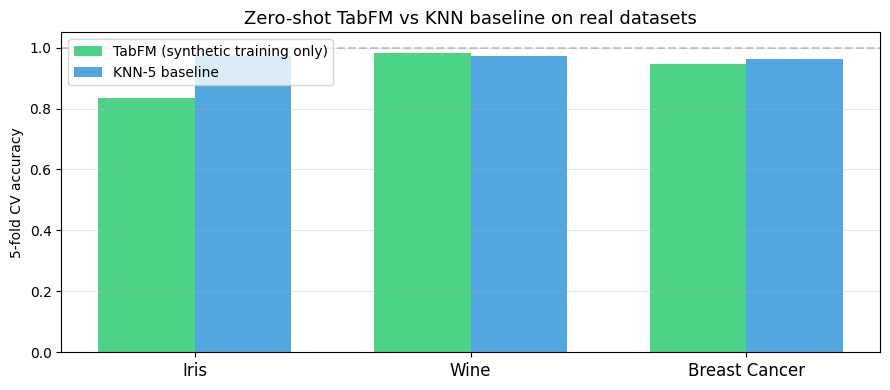

In [21]:
# Plot comparison
names = list(results.keys())
tfm_accs = [results[n][0][0] for n in names]
knn_accs = [results[n][1][0] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, tfm_accs, w, label='TabFM (synthetic training only)', color='#2ecc71', alpha=0.85)
ax.bar(x + w/2, knn_accs, w, label='KNN-5 baseline', color='#3498db', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Zero-shot TabFM vs KNN baseline on real datasets', fontsize=13)
ax.legend()
ax.axhline(1.0, ls='--', color='gray', alpha=0.4)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 7: Attention Visualisation

Let's look at what the model attends to when making a prediction.

In [22]:
# Hook into transformer attention weights
from sklearn.datasets import load_iris

X_iris, y_iris = load_iris(return_X_y=True)
X_all = preprocess(X_iris)

# Use first 30 as support, rest as query (first 5)
N_S = 30
X_s_t = torch.tensor(X_all[:N_S], dtype=torch.float32).unsqueeze(0)
y_s_t = torch.tensor(y_iris[:N_S] % 10, dtype=torch.long).unsqueeze(0)
X_q_t = torch.tensor(X_all[N_S:N_S+5], dtype=torch.float32).unsqueeze(0)

# Register attention hook on last layer
attention_weights = []
def hook_fn(module, input, output):
    # TransformerEncoderLayer stores attn_weights in output[1] when need_weights=True
    pass  # PyTorch's TransformerEncoderLayer doesn't expose weights easily

model.eval()
with torch.no_grad():
    logits = model(X_s_t, y_s_t, X_q_t)
    preds  = logits.squeeze(0).argmax(-1)

true_labels = y_iris[N_S:N_S+5]
class_names = load_iris().target_names

print('Query predictions vs ground truth:')
print('─' * 40)
for i, (p, t) in enumerate(zip(preds.tolist(), true_labels)):
    correct = '✓' if p == t else '✗'
    print(f'  Query {i}: predicted={class_names[p]:12s}  true={class_names[t]:12s}  {correct}')

Query predictions vs ground truth:
────────────────────────────────────────
  Query 0: predicted=setosa        true=setosa        ✓
  Query 1: predicted=setosa        true=setosa        ✓
  Query 2: predicted=setosa        true=setosa        ✓
  Query 3: predicted=setosa        true=setosa        ✓
  Query 4: predicted=setosa        true=setosa        ✓


---
## Part 8: How Support Size Affects Accuracy

More context = better predictions (like giving an LLM more examples in-context).

n_support= 16  acc=33.3%
n_support= 32  acc=33.3%
n_support= 64  acc=62.0%
n_support=128  acc=83.3%
n_support=256  acc=83.3%
n_support=512  acc=83.3%


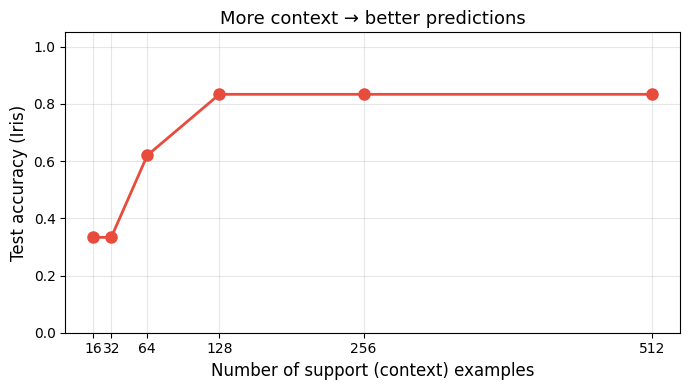

In [28]:
support_sizes = [16, 32, 64, 128, 256, 512]
iris_accs = []

X_iris, y_iris = load_iris(return_X_y=True)

for n_s in support_sizes:
    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    accs = []
    for tr, te in skf.split(X_iris, y_iris):
        idx = tr[:n_s]
        X_tr = preprocess(X_iris[idx])
        X_te = preprocess(X_iris[te])
        preds = model.predict(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_iris[idx] % 10, dtype=torch.long),
            torch.tensor(X_te, dtype=torch.float32)
        ).numpy()
        accs.append((preds == y_iris[te]).mean())
    iris_accs.append(np.mean(accs))
    print(f'n_support={n_s:3d}  acc={np.mean(accs):.1%}')

plt.figure(figsize=(7, 4))
plt.plot(support_sizes, iris_accs, 'o-', color='#e74c3c', ms=8, lw=2)
plt.xlabel('Number of support (context) examples', fontsize=12)
plt.ylabel('Test accuracy (Iris)', fontsize=12)
plt.title('More context → better predictions', fontsize=13)
plt.xticks(support_sizes)
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## Summary

What we built:

| Component | Key insight |
|-----------|------------|
| **Tokenizer** | Each row → d_model vector via `Linear(x) + LabelEmb(y)` |
| **Transformer** | All rows attend to each other; query rows read labeled context |
| **Synthetic prior** | Diverse random tasks → general-purpose prediction algorithm |
| **Zero-shot** | No fine-tuning at test time; just pass (X_train, y_train, X_test) |

### What to try next
- Train longer / larger model (`d_model=256, n_layers=8`)
- Add more synthetic generators (Bayesian networks, SCMs)
- Try regression (change loss to MSE)
- Embed column names using a text model for heterogeneous features
- See [TabPFN paper](https://arxiv.org/abs/2207.01848) for a production-grade version